# EDA NPS

# EDA Tech Challange 1 - Net Promoter Score

## 1. Introdução do Problema

### 1.1. O que é NPS?

O **Net Promoter Score (NPS)** é uma métrica amplamente utilizada para medir a satisfação e a lealdade dos clientes em relação a uma empresa, produto ou serviço. Criado por Fred Reichheld em 2003, o NPS é baseado em uma única pergunta: *"Em uma escala de 0 a 10, qual a probabilidade de você recomendar nossa empresa a um amigo ou colega?"*

Com base na nota atribuída, os clientes são classificados em três grupos:

- **Promotores (9–10):** clientes altamente satisfeitos, que tendem a recomendar a empresa e contribuir para o crescimento orgânico.
- **Neutros (7–8):** clientes satisfeitos, mas sem entusiasmo suficiente para recomendar ativamente.
- **Detratores (0–6):** clientes insatisfeitos, que podem prejudicar a reputação da empresa por meio de avaliações negativas.

O score final é calculado pela fórmula:

> **NPS = % Promotores − % Detratores**

O resultado varia de **−100** (todos detratores) a **+100** (todos promotores). Valores acima de 0 já são considerados positivos, e acima de 50 são considerados excelentes.

---

#### Problema de Negócio

Com o crescimento acelerado do e-commerce nacional, a empresa passou a lidar com um volume cada vez maior de pedidos, entregas e interações com clientes. Esse crescimento trouxe ganhos importantes de escala, mas também revelou desafios relevantes na experiência do cliente, especialmente refletidos na **alta variabilidade do NPS entre diferentes perfis de consumidores**.

A área de Experiência do Cliente identificou que, mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca enquanto outros se tornam detratores. Atualmente, o NPS é coletado **apenas após o encerramento da jornada de compra**, o que limita a capacidade da empresa de:

- Antecipar problemas antes que afetem a satisfação;
- Priorizar ações corretivas de forma proativa;
- Atuar preventivamente para melhorar a experiência do cliente.

Nesse contexto, surge a necessidade de **transformar dados operacionais** — como informações de pedidos, logística e atendimento — em **insights acionáveis**, capazes de orientar decisões estratégicas nas áreas de logística, atendimento, produto e estratégia.

---

Essa diferença levanta uma questão central para o negócio: quais **fatores operacionais** realmente **influenciam a satisfação do cliente** e **como a empresa pode agir de forma proativa para melhorar a experiência** antes mesmo da aplicação da pesquisa de NPS?

## 2. Importação de bibliotecas e configurações iniciais

In [ ]:
#Importar as bibliotecas
import pandas as pd
import numpy as np
# bibliotecas para gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ferramentas do modelo preditivo
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# configurações padrões dos graficos
plt.style.use("default")
sns.set(style="whitegrid")

# Configuração padrão de tamanho dos gráficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 3. Contexto e carregamento dos dados


In [ ]:
# Carregamento dos dados direto do GitHub
url = "https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv"
df_nps = pd.read_csv(url)

# Informações gerais sobre os dados, colunas, linhas e tipo
df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

### 3.1 Visão geral dos dados, podemos visualizar as colunas e entender o que temos em cada coluna.

In [ ]:
df_nps.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


## 4. Estrutura do dataset

In [ ]:
# Mostra dados de estatistica descritiva dos dados
# Removemos o customer_id e o order_id pois são dados de registro do banco de
# dados e de natureza sequencial

df_nps.drop(columns=['customer_id','order_id']).describe().drop('count')

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
mean,43.396000,61.322400,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,14.888487,34.478729,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,18.000000,1.000000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,31.000000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,43.000000,62.000000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,56.000000,91.000000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,69.000000,119.000000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


**bold text**# New Section

In [ ]:
df_nps.shape
print(f'Tamanho do nosso Dataset (Linhas, Colunas): {df_nps.shape}')

Tamanho do nosso Dataset (Linhas, Colunas): (2500, 19)


## 5. Qualidade dos dados


In [ ]:
# Verificando que não temos valores de NPS acima de 0 ou acima de 10
len(df_nps[(df_nps['nps_score'] < 0) | (df_nps['nps_score'] > 10)])

0

In [ ]:
cols_non_negative = ['delivery_delay_days', 'complaints_count',
                     'customer_service_contacts', 'resolution_time_days']
(df_nps[cols_non_negative] < 0).sum()

,0
delivery_delay_days,0
complaints_count,0
customer_service_contacts,0
resolution_time_days,0


### 5.1 Valores Nulos

In [ ]:
# Verifica valores nulos
df_nps.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [ ]:
# Verifica linhas duplicadas
df_nps.duplicated().sum()

np.int64(0)

In [ ]:
# Verifica valores únicos
df_nps.nunique()

,0
customer_id,2500
customer_age,52
customer_region,5
customer_tenure_months,119
order_id,2500
order_value,2457
items_quantity,6
discount_value,2050
payment_installments,11
delivery_time_days,13


##  6. Panorama Geral do NPS

Sabe-se que um dado de interesse é o NPS Score. Iniciamos entendendo o panorama geral desta variavel, para tal, podemos questionar, dado um NPS classificado, quantas ocorrências temos de cada classe.

Notamos na parte 3, de contexto e carregamento dos dados que o NPS possui valores decimais, não inteiros. Para realizar a classificação, precisamos decidir o que fazer com esses valores.

Se entendermos que estes dados são confiáveis, os valores decimais podem ser fruto de:
- Média ou agregação de pontuações de múltiplas pesquisas
- Pontuação ajustada por alguma fórmula

##### Nota: o nps_score original possui uma casa decimal.
##### Arredondamos para inteiro pois a metodologia oficial do NPS trabalha com notas de 0 a 10 sem decimais.
##### Isso evita ambiguidade na classificação (ex: 6.7 é detrator ou neutro?)

/tmp/ipykernel_16207/4007464705.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_nps, x='nps_class_round', order=ordem, palette=cores)


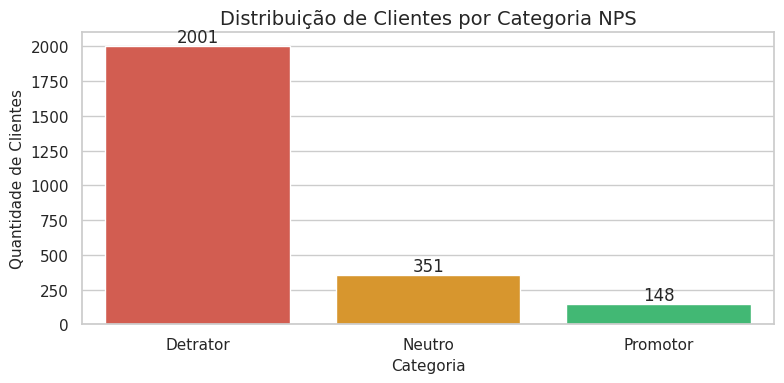

Insight: 84% dos clientes são detratores — situação crítica.


In [ ]:
# GRÁFICO 1 — Distribuição de Promotores, Neutros e Detratores
plt.figure(figsize= (8,4))

# Conta quantos clientes há em cada categoria e plota em barras
ordem = ['Detrator', 'Neutro', 'Promotor']
cores = ['#e74c3c', '#f39c12', '#2ecc71']  # vermelho, amarelo, verde

ax = sns.countplot(data=df_nps, x='nps_class_round', order=ordem, palette=cores)

# Adiciona o número em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Clientes por Categoria NPS', fontsize=14)
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

# Insight para o negócio
print("Insight: 84% dos clientes são detratores — situação crítica.")

In [ ]:
# 6.1 - Função para classificar as notas do NPS contendo valores decimais

# Helper functions
def classifica_nps(score):
  if score <= 6:
    return 'Detrator'
  elif score <= 8:
    return 'Neutro'
  else:
    return 'Promotor'

# Quantidade de notas em cada classe

df_nps['nps_class'] = df_nps['nps_score'].apply(classifica_nps)

display(df_nps['nps_class'].value_counts())

,count
nps_class,
Detrator,1851
Neutro,448
Promotor,201


In [ ]:
# 6.2 - Função para classificar as notas do NPS contendo valores inteiros

# Arredondar para o inteiro mais próximo (ROUND)
df_nps['nps_score_round'] = df_nps['nps_score'].apply(round)

# Classificar com base no score arredondado
df_nps['nps_class_round'] = df_nps['nps_score_round'].apply(classifica_nps)

print("\nPorcentagem de cada classe NPS (arredondamento ROUND):")
percentage_nps_round = df_nps['nps_class_round'].value_counts()
display(percentage_nps_round)

print("\nComparativo das porcentagens de Detratores, Neutros e Promotores:")
comparison_df = pd.DataFrame({
    'NPS_Class_Original': df_nps['nps_class'].value_counts(normalize=True) * 100,
    'NPS_Class_Round': percentage_nps_round
})
display(comparison_df.sort_index())


Porcentagem de cada classe NPS (arredondamento ROUND):


,count
nps_class_round,
Detrator,2001
Neutro,351
Promotor,148



Comparativo das porcentagens de Detratores, Neutros e Promotores:


,NPS_Class_Original,NPS_Class_Round
Detrator,74.04,2001
Neutro,17.92,351
Promotor,8.04,148


In [ ]:
# 6.3 reordenando as colunas, trazendo a coluna com valores de NPS inteiros (round) para o lado da coluna com valores de NPS
#decimais (float)

# Lista com a ordem desejada das colunas
columns = df_nps.columns.tolist()
# Remova 'nps_score_round' da sua posição atual
columns.remove('nps_score_round')
# Encontre o índice de 'nps_score'
idx = columns.index('nps_score')
# Insira 'nps_score_round' após 'nps_score'
columns.insert(idx + 1, 'nps_score_round')
# Reordene o DataFrame
df_nps = df_nps[columns]

print("DataFrame com 'nps_score_round' após 'nps_score':")
display(df_nps.head())

DataFrame com 'nps_score_round' após 'nps_score':


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,nps_score_round,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class,nps_class_round
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,3,0,4,6.9,7,0,3,6.5,Neutro,Neutro
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,3,0,10,2.4,2,0,3,0.0,Detrator,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,1,4,5,4.8,5,0,7,1.5,Detrator,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,3,1,11,5.9,6,0,4,0.3,Detrator,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,1,1,0,6.1,6,0,3,7.9,Neutro,Detrator


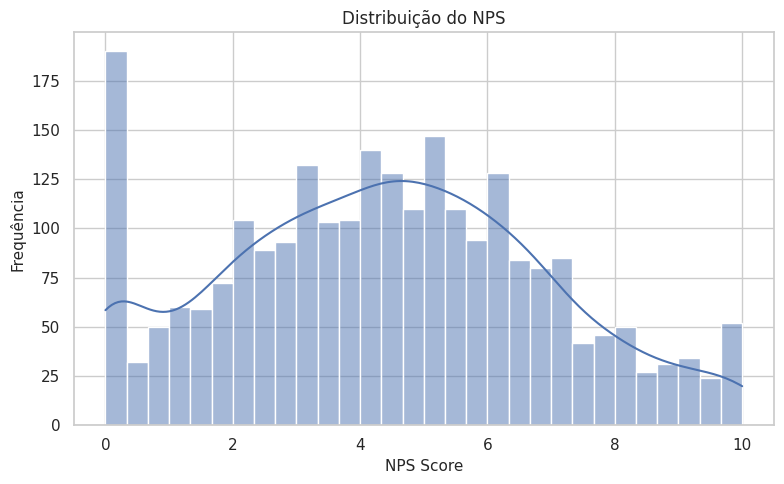

In [ ]:
# 6.4 Histograma do NPS

sns.histplot(df_nps["nps_score"], bins=30, kde=True)
plt.title("Distribuição do NPS")
plt.xlabel("NPS Score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

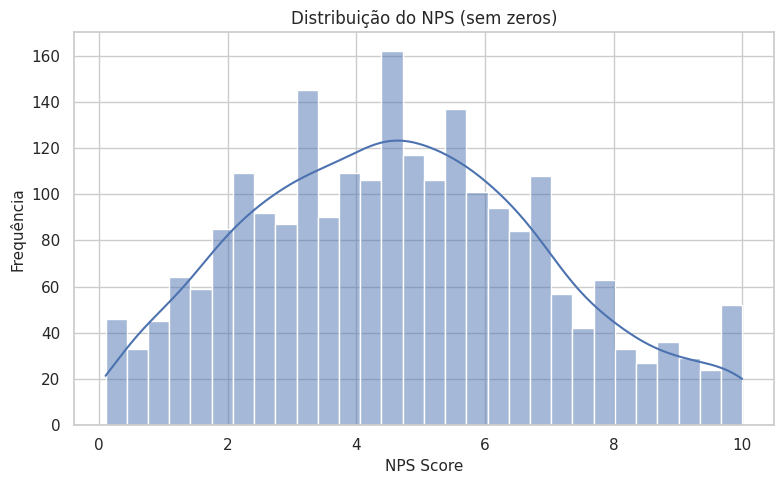

In [ ]:
# 6.4 Histograma do NPS removendo-se os zeros

sns.histplot(df_nps[df_nps["nps_score"] > 0]["nps_score"], bins=30, kde=True)
plt.title("Distribuição do NPS (sem zeros)")
plt.xlabel("NPS Score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

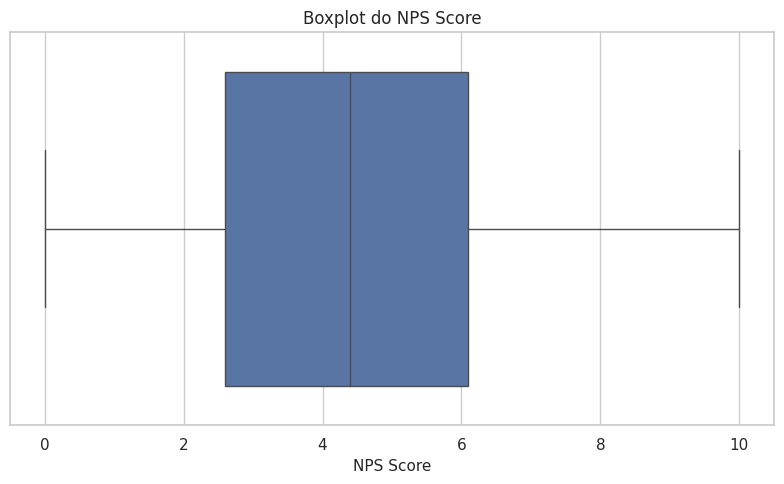

In [ ]:
# 6.5 Boxplot geral do NPS

sns.boxplot(x=df_nps["nps_score"])
plt.title("Boxplot do NPS Score")
plt.xlabel("NPS Score")
plt.tight_layout()
plt.show()

In [ ]:
# 6.6 Medidas resumo do NPS

df_nps["nps_score"].agg(["mean", "median", "min", "max"])

,nps_score
mean,4.3786
median,4.4000
min,0.0000
max,10.0000


Realizando um gráfico de correlação de Pearson podemos observar as variáveis que possuem correlação entre si. Notamos que uma grande parte das variáveis dos nossos dados não possuem correlação.

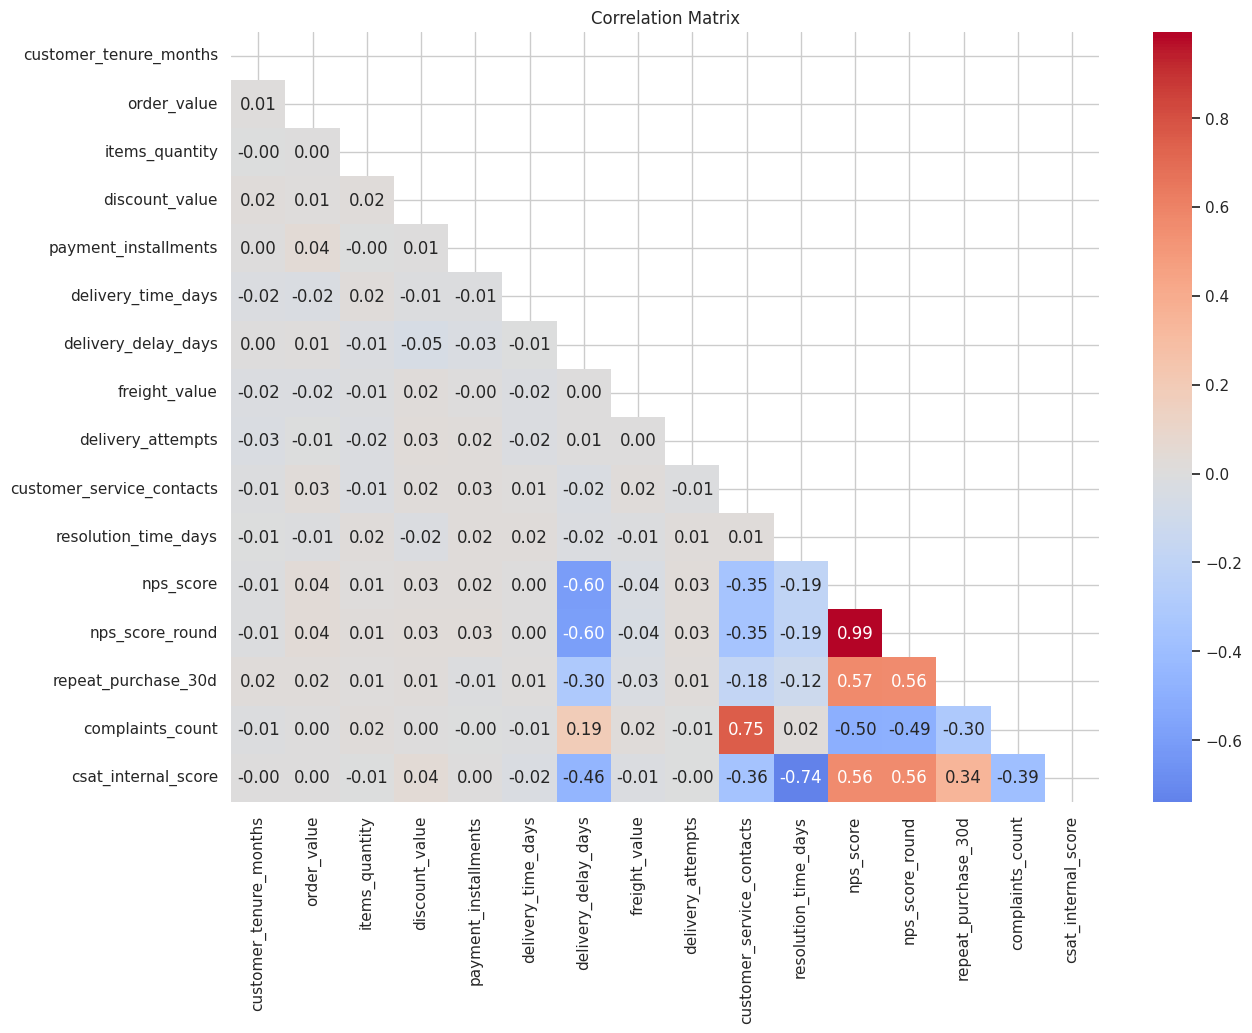

In [ ]:
.corr = df_nps.drop(columns=['customer_id','order_id','nps_class','nps_class_round','customer_region', 'customer_age']).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
              mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('Correlation Matrix')

plt.show()

Porém, há um conjunto delas que mostram forte relação, podemos elaborar um gráfico de correlação apenas com essas variáveis.

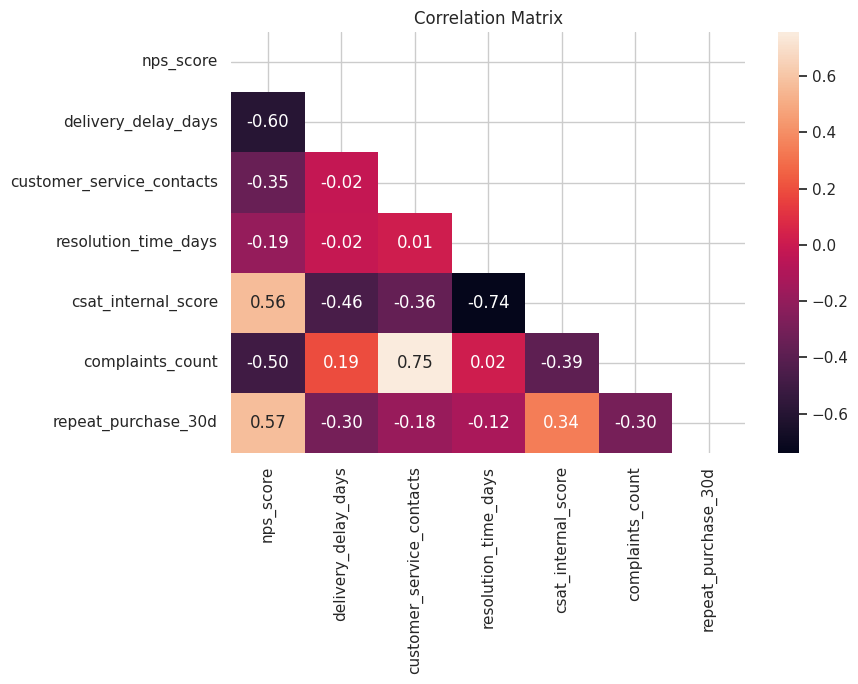

In [ ]:
cols = ['nps_score', 'delivery_delay_days', 'customer_service_contacts',
        'resolution_time_days', 'csat_internal_score', 'complaints_count', 'repeat_purchase_30d']

corr = df_nps[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket', center=0,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
cols = ['nps_score', 'delivery_delay_days', 'complaints_count', 'customer_service_contacts',
        'resolution_time_days', 'csat_internal_score', 'repeat_purchase_30d']

corr_with_nps = df_nps[cols].corr()['nps_score'].drop('nps_score').abs().sort_values(ascending=False)
print(corr_with_nps)

delivery_delay_days          0.597260
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
complaints_count             0.496800
customer_service_contacts    0.350845
resolution_time_days         0.191392
Name: nps_score, dtype: float64


### 7. Explorando as variáveis correlacionadas ao NPS

Entende-se que algumas das variáveis que mostram forte correlação com o NPS não entram no contexto de solução do problema, pois são conhecidas apenas após o fluxo de compra.

Sendo elas:
- Resolution time days: Conhecida apenas após a solução do problema/ticket. Portanto, não pode ser um indicador do NPS.
- Repeat Purchase 30d: Também é conhecida apenas no fim do processo e para clientes que já realizaram compras anteriores.

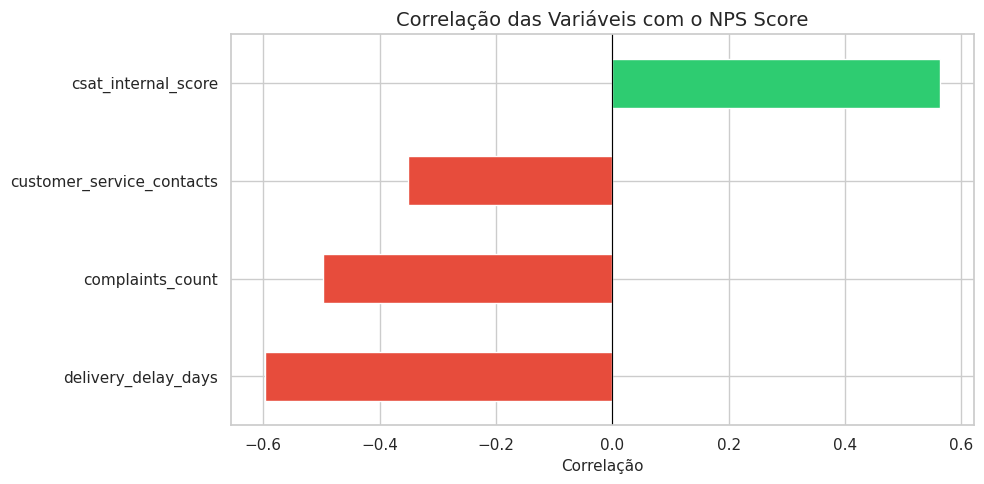

In [ ]:
#Correlação das variáveis com o NPS
cols_corr = ['delivery_delay_days', 'customer_service_contacts', 'csat_internal_score', 'complaints_count']

# Calcula a correlação de cada variável com o nps_score
correlacoes = df_nps[cols_corr + ['nps_score']].corr()['nps_score'].drop('nps_score')
correlacoes = correlacoes.sort_values()

# Define cor: vermelho se negativo, verde se positivo
cores_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlacoes]

plt.figure(figsize=(10,5))
correlacoes.plot(kind='barh', color=cores_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação das Variáveis com o NPS Score', fontsize=14)
plt.xlabel('Correlação')
plt.tight_layout()
plt.show()


### 7.1. Entendendo a correlação por região

Como região não é uma variável númerica, não podemos analisa-la através da correlação. Portanto, iremos investigar se há relação do NPS com região.

In [ ]:
# Validar se o NPS é influenciado por região

nps_by_region = df_nps.groupby('customer_region')['nps_class'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Calcular o NPS usando a fórmula: % Promotores - % Detratores
nps_by_region['NPS'] = nps_by_region['Promotor'] - nps_by_region['Detrator']

print("NPS por Região:")
display(nps_by_region[['Promotor', 'Neutro', 'Detrator', 'NPS']].sort_values(by='NPS', ascending=False))

import plotly.express as px

nps_by_region = df_nps.groupby('customer_region')['nps_class'].value_counts(normalize=True).unstack(fill_value=0) * 100
nps_by_region['NPS'] = nps_by_region['Promotor'] - nps_by_region['Detrator']
nps_by_region = nps_by_region['NPS'].sort_values().reset_index()
nps_by_region.columns = ['Região', 'NPS']

fig = px.bar(
    nps_by_region,
    width=800,
    height=500,
    x='Região',
    y='NPS',
    color='NPS',
    color_continuous_scale=['steelblue' , 'steelblue'],
    title='NPS Score por Região',
    labels={'NPS': 'NPS Score (%)'},
    text='NPS'
    )

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)
fig.update_layout(coloraxis_showscale=False)

fig.show()

NPS por Região:


nps_class,Promotor,Neutro,Detrator,NPS
customer_region,,,,
Sul,9.596929,17.658349,72.744722,-63.147793
Sudeste,8.269231,17.115385,74.615385,-66.346154
Centro-Oeste,7.692308,17.948718,74.358974,-66.666667
Norte,7.509881,17.984190,74.505929,-66.996047
Nordeste,7.010309,18.969072,74.020619,-67.010309


Notamos que apesar de um NPS ligeiramente maior no sul, ainda é um NPS significativamente negativo, de forma que região não é um fator decisivo na nota no NPS, não há uma região puxando para baixo a nota do NPS que poderia indicar algum problema de logística localizado.

### 7.2. Delivery Delay Days

#### Impacto do Atraso na Entrega sobre o NPS

O atraso na entrega é o fator com maior correlação negativa com o
NPS. A análise revela um padrão claro de tolerância por
perfil de cliente:

- 🟢 **Promotores** desaparecem a partir de 5 dias de atraso
- 🟡 **Neutros** resistem até 4 dias antes de virarem detratores
- 🔴 **Detratores** estão presentes em todos os níveis de atraso

**Ponto de ruptura:** a partir de 6 dias, a base é 100% detratores.

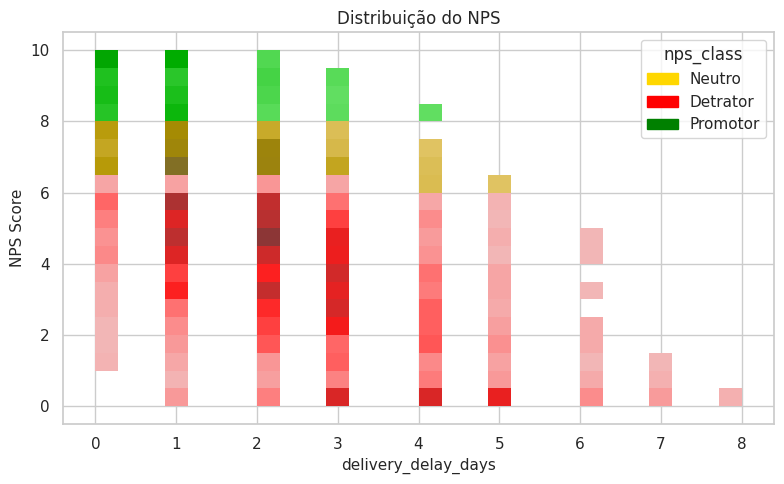

In [ ]:
sns.histplot(data = df_nps, x = "delivery_delay_days", y = "nps_score", hue="nps_class",
             palette={'Detrator': 'red', 'Neutro': 'gold', 'Promotor': 'green'})
plt.title("Distribuição do NPS")
plt.xlabel("delivery_delay_days")
plt.ylabel("NPS Score")
plt.tight_layout()
plt.show()

### O atraso como ponto de ruptura
A tabela revela um padrão claro de tolerância ao atraso por perfil de cliente.
Promotores desaparecem a partir de 5 dias de atraso. Neutros a partir de 5 dias também. Detratores persistem em todos os níveis — inclusive quando não há atraso.

O ponto crítico está entre 2 e 4 dias: é nessa faixa que promotores e neutros migram para detratores de forma acelerada.

Conclusão: a partir de 5 dias de atraso, a empresa só tem detratores. Esse é o ponto de ruptura irreversível da experiência do cliente.

In [ ]:
df_nps.groupby(['delivery_delay_days', 'nps_class']).size().unstack(fill_value=0)

nps_class,Detrator,Neutro,Promotor
delivery_delay_days,,,
0,101,90,86
1,367,162,86
2,487,137,22
3,471,48,6
4,259,10,1
5,115,1,0
6,34,0,0
7,14,0,0
8,3,0,0


In [ ]:
# Ponto de rupturadel delivery delay days
avg_nps = df_nps.groupby('delivery_delay_days')['nps_score'].mean().round(2)
delay_df = avg_nps.to_frame()
delay_df['drop'] = delay_df['nps_score'].diff().round(2)
delay_df['drop'] = delay_df['drop'].apply(lambda x: f"{x:+.2f}" if pd.notna(x) else "—")

display(delay_df)

,nps_score,drop
delivery_delay_days,,
0,6.86,—
1,5.55,-1.31
2,4.58,-0.97
3,3.44,-1.14
4,2.44,-1.00
5,1.48,-0.96
6,1.10,-0.38
7,0.29,-0.81
8,0.00,-0.29


### 7.3. Complaints Counts

### Impacto do Número de Reclamações sobre o NPS

O número de reclamações é o segundo fator com maior correlação
negativa com o NPS. O padrão é semelhante ao do atraso,
mas com uma diferença importante:

- 🟢 **Promotores** resistem até 3 reclamações, com 75% dos promotores com 3 ou menos reclamações. Sendo que não existem promotores após cinco reclamções (exceto outliers).
- 🟡 **Neutros** resistem até 4 reclamações, com 75% dos promotores com 3 ou menos reclamações.
- 🔴 **Detratores** dominam a partir de 6 reclamações

**Diferença em relação ao atraso:** enquanto o atraso elimina
promotores rapidamente, o número de reclamações tem um comportamento
mais irregular — há promotores mesmo com muitas reclamações.
Isso sugere que **o que importa não é só quantas reclamações
o cliente fez, mas se elas foram resolvidas.**

**Conclusão:** reclamações mal resolvidas são mais danosas
ao NPS do que o volume de reclamações em si.

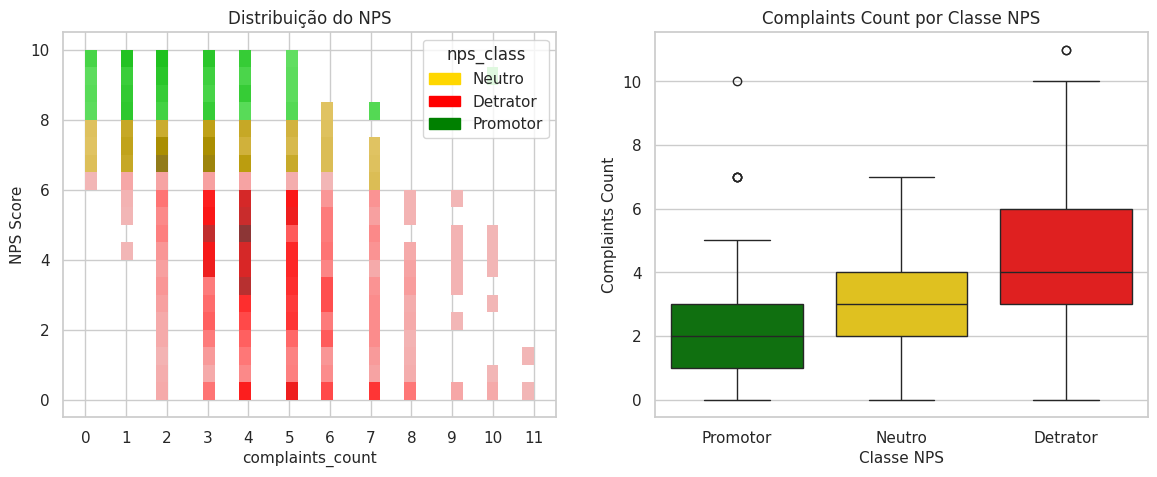

In [ ]:
# Histograma complains count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data = df_nps, x = "complaints_count", y = "nps_score", hue="nps_class",
             palette={'Detrator': 'red', 'Neutro': 'gold', 'Promotor': 'green'},
             ax=axes[0])
axes[0].set_title("Distribuição do NPS")
axes[0].set_xlabel("complaints_count")
axes[0].set_ylabel("NPS Score")
start, end = 0, 11
axes[0].set_xticks(np.arange(start, end + 1, 1))

sns.boxplot(data=df_nps, x="nps_class", y="complaints_count", hue="nps_class",
            palette={'Detrator': 'red', 'Neutro': 'gold', 'Promotor': 'green'},
            order=['Promotor', 'Neutro', 'Detrator'],
            ax=axes[1])
axes[1].set_title("Complaints Count por Classe NPS")
axes[1].set_xlabel("Classe NPS")
axes[1].set_ylabel("Complaints Count")
plt.show()

As reclamações como ponto de ruptura

A tabela revela um padrão claro da tolerância ao número de reclamações por perfil de cliente.

- Promotores desaparecem a partir de 4 reclamações.
- Neutros a partir de 6.
- Detratores começam a surgir a partir de 2 reclamações, e a média começa a estabilizar após 4 reclamações.

O ponto crítico está entre 2 e 4 reclamações: é nessa faixa que promotores e neutros migram para detratores de forma acelerada.

Conclusão: a partir de 2 reclamações a média do NPS em relação à complaints cai para detratora, e a partir de 5 os clientes migram para detratores.

In [ ]:
df_nps.groupby(['complaints_count', 'nps_class']).size().unstack(fill_value=0)

nps_class,Detrator,Neutro,Promotor
complaints_count,,,
0,1,8,14
1,10,61,51
2,120,107,50
3,343,123,41
4,487,82,31
5,392,43,9
6,249,17,0
7,158,7,4
8,63,0,0


In [ ]:
# Ponto de ruptura complaints count
avg_nps = df_nps.groupby('complaints_count')['nps_score'].mean().round(2)
complaint_df = avg_nps.to_frame()
complaint_df['drop'] = complaint_df['nps_score'].diff().round(2)
complaint_df['drop'] = complaint_df['drop'].apply(lambda x: f"{x:+.2f}" if pd.notna(x) else "—")

display(complaint_df)

,nps_score,drop
complaints_count,,
0,8.52,—
1,7.77,-0.75
2,6.05,-1.72
3,4.91,-1.14
4,4.22,-0.69
5,3.65,-0.57
6,3.06,-0.59
7,2.81,-0.25
8,2.07,-0.74


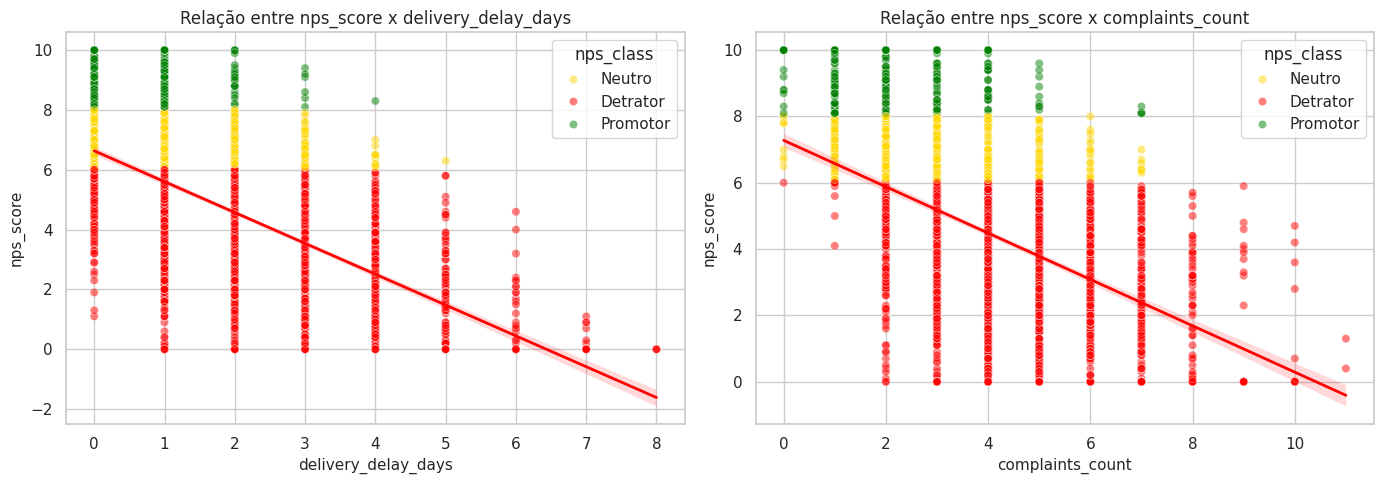

In [ ]:

sns.scatterplot(data=df_nps, x="delivery_delay_days", y="nps_score", alpha=0.5, ax = axes[0], hue="nps_class",
             palette={'Detrator': 'red', 'Neutro': 'gold', 'Promotor': 'green'})

# Linha de tendência com regplot
sns.regplot(
         data=df_nps,
        x="delivery_delay_days",
        y="nps_score",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2}, # deixa a linha mais grossa
        ax = axes[0]

    )
axes[0].set_title("Relação entre nps_score x delivery_delay_days")
plt.title("Relação entre nps_score x delivery_delay_days")
plt.xlabel("delivery_delay_days")
plt.ylabel("nps_score")
plt.tight_layout()

# 2º grafico
sns.scatterplot(data=df_nps, x="complaints_count", y="nps_score", alpha=0.5, ax = axes[1], hue="nps_class",
             palette={'Detrator': 'red', 'Neutro': 'gold', 'Promotor': 'green'})

# Linha de tendência com regplot
sns.regplot(
         data=df_nps,
        x="complaints_count",
        y="nps_score",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2}, # deixa a linha mais grossa
        ax = axes[1]
    )
axes[1].set_title("Relação entre nps_score x complaints_count")
plt.title("Relação entre nps_score x complaints_count")
plt.xlabel("complaints_count")
plt.ylabel("nps_score")
plt.tight_layout()
plt.show()



### 7.4 Média por Perfil de Clientes

Analisando a média por perfil de clientes, considerando pouco atraso e baixa número de reclamações dado a base de dados, conseguimos identificar que o cliente com a melhor nota de NPS é o que possui um pouco atraso em conjunto com baixo número de reclamações.

Avg NPS Score by Group:
----------------------------------------
  Low Delay (<2d)                5.38
  Low Complaints (<2)            5.72
  Low Delay + Low Complaints     6.62
  Overall Average                4.38


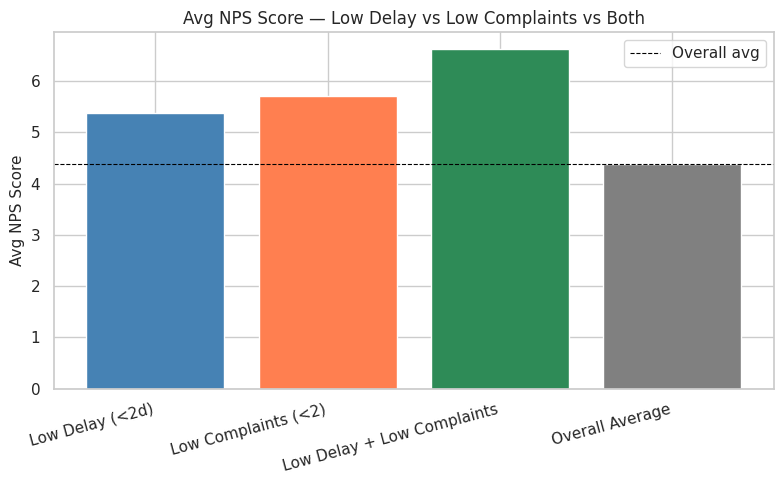

In [ ]:
# Define groups
low_delay      = df_nps['delivery_delay_days'] < 3
low_complaints = df_nps['complaints_count'] < 4

groups = {
    'Low Delay (<2d)':               df_nps[low_delay]['nps_score'].mean(),
    'Low Complaints (<2)':           df_nps[low_complaints]['nps_score'].mean(),
    'Low Delay + Low Complaints':    df_nps[low_delay & low_complaints]['nps_score'].mean(),
    'Overall Average':               df_nps['nps_score'].mean()
}

# Print table
print("Avg NPS Score by Group:")
print("-" * 40)
for group, avg in groups.items():
    print(f"  {group:<30} {avg:.2f}")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(groups.keys(), groups.values(), color=['steelblue', 'coral', 'seagreen', 'gray'])
plt.title('Avg NPS Score — Low Delay vs Low Complaints vs Both')
plt.ylabel('Avg NPS Score')
plt.xticks(rotation=15, ha='right')
plt.axhline(df_nps['nps_score'].mean(), color='black', linewidth=0.8, linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Consolidação

### Quais fatores parecem mais críticos para a satisfação?

Através da exploração dos dados, nota-se algumas variáveis com alta correlação com a variável de interesse (NPS Score), porém, o problema em questão lida com os fatores operacionais durante a jornada e algumas das variáveis são indicadores no fim da jornada, próximo ao NPS.

Dois fatores que possuem alta correlação com o NPS são os atrasos na entrega e o número de reclamações dos clientes com o suporte, sendo:

- Atraso de entrega, registrado por 'delivery_delay_days', sendo um fator logístico;
- A quantidade de reclamações, registrado pelo 'complaints_counts', sendo um fator de atendimento.

### O que mais gera detratores?

A principal causa de detratores são os atrasos, apenas um dia de atraso já leva a média do NPS para o nível de detrator, após três dias de atraso na entrega todos os clientes passam a ser neutros ou detratores.

Assim como o número de reclamações, considerando clientes com 0 reclamações, o NPS médio é de 8.5, após duas reclamações, o NPS cai para 6.

### Existe algum “ponto de ruptura” na experiência do cliente?

Temos um ponto de ruptura para o delivery_delay_days, entre 2 a 4 dias de entrega é o ponto onde os clientes passam de promotores e neutros para detratores de forma acelerada.

Algo similar ocorre para o complaints_counts, em que a média do NPS em relação aos números de reclamações cai para níveis de detrator após 2 reclamações, e após 5 reclamações a grande maioria dos clientes já estão como detratores.


### Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Clientes com pouco atraso e baixo número de reclamações são os clientes com o maior NPS, os clientes com ambas as características baixas são os clientes com o NPS mais alto.


Clientes com muito atraso em seus pedidos são os com nota de NPS mais baixo.

